# 👗 Smart Fashion AI with Neural Networks (Mid Term)

**Total Marks: 100 (Theory: 10 | Practical: 90)**  


---

**Instructions:**
1. Enter your course email in the cell below.
2. Read the story and problem descriptions carefully.
3. Complete the code in cells containing `# YOUR CODE HERE`. Do not modify the test cells.
4. Run all cells sequentially to ensure your tests pass before submitting.
5. Have fun!

In [5]:
# Enter your course email here
student_email = "hridoybanik.eee@gmail.com"

---

## 📖 Story: StyleAI — Smart Fashion Recognition

You've just joined **StyleAI**, a startup building an AI-powered wardrobe assistant app. The app lets users snap a photo of any clothing item and instantly classifies it. Your job is to build the **image classification model** that powers this feature.

The dataset is **Fashion-MNIST** — 28×28 grayscale images of 10 clothing categories:

| Label | Class Name |
|-------|------------|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |


---

## Question 1: Theory (10 Marks)

### Part A (3 Marks)
Explain the difference between **Sigmoid** and **ReLU** activation functions. Why is ReLU preferred in hidden layers of deep networks? What problem does Sigmoid cause during backpropagation in deep networks?

### Part B (4 Marks)
In the context of **Gradient Descent**:
- What is the difference between **Batch Gradient Descent**, **Stochastic Gradient Descent (SGD)**, and **Mini-batch Gradient Descent**?
- State one advantage and one disadvantage of each.
- Which type would you recommend for training on Fashion-MNIST (60,000 images), and why?

### Part C (3 Marks)
In our Fashion-MNIST problem (10 classes):
1. Why do we use `nn.CrossEntropyLoss` instead of `nn.BCELoss`?
2. Why should we **NOT** put `nn.Softmax` as the last layer when using `nn.CrossEntropyLoss`?
3. What does `loss.backward()` do?

*Double-click here to write your answers*

**Part A Answer:**
Difference between Sigmoid and ReLU:

It provides output from 0 to 1. In a deep neural network, the gradient could be very small. That may cause dying neuron problem or very slow convergence. ReLU changes the negative input into 0 and positive input as it is.   

ReLU is preferred in hidden layers because it works very fast and it reduces the probability of gradient vanishing.   

Sigmoid creates vanishing gradient problem during backpropagation. As a result, the previous layers of deep networks learn very slowly.   




**Part B Answer:**
1.  
For Batch Gradient Descent, it would update once after the full dataset being trained. Example: If there are 100 images or datapoints, then it will update once after the operation being done on 100 points or images.

In terms of Stochastic Gradient Descent (SGD), it would update after every datapoint. For the previous example, it would 100 times for 100 datapoints or images.

For Mini Batch Gradient Descent, We split the data according to the batch size, like 2, 4, 8, 16 (Multiplication of 2's), then based on that, we update the gradient.
Like if there is 10 data points, and if we are using batch size 2. Then there will be 5 batches containing 2 data points in each. As a result, the gradient will be updated 5 times.
2.

Advantages and Disadvantages:

Batch Gradient Descent:
Advantage:
1. Gradient stable and accurate.
Disadvantage:
1. Requires huge memory and computation.

Stochastic Gradient Descent (SGD):
Advantage:
1. Faster update and requires less memory
Disadvantages:
1. Too much noisy and jittery and unstable training


Mini-Batcy Gradient Descent:
Advantage:
1. Fast and comparably accurate. Efficient GPU uses
Disadvantage:
1. Needs to find the right batch size.

3.
I will choose mini batch gradient descent for Fashion MNIST. If we use the full dataset, then, it would requires huge computation power. And if we use SGD, then the training would be noisy.




**Part C Answer:**

BCE is used for binary classes. In this dataset there are 10 classes. So for multi class classification, we use CrossEntropy rather than Binary cross entropy

nn.CrossEntropyLoss contains SoftMax and Log calculation. We don't need to put it by ourselves.

loss.backward() is basically used for backpropagation. It calculats gradient.

---

## Question 2: Load & Explore the Data (15 Marks)

### 2.1 Download the Dataset (1 Marks)

We will use `torchvision.datasets.FashionMNIST` to download the dataset. This is similar to how we loaded data from `.npy` files in class, but here PyTorch handles the download for us.

Run the cell below to download the training and test sets:

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Download Fashion-MNIST — this downloads the data into a ./data folder
# download=True means it will download if not already present
full_train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
test_dataset_raw = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

train_images_all = full_train_dataset.data.numpy()  # shape: (60000, 28, 28)
train_labels_all = full_train_dataset.targets.numpy()  # shape: (60000,)
test_images_all = test_dataset_raw.data.numpy()
test_labels_all = test_dataset_raw.targets.numpy()

print(f"Training set size: {len(full_train_dataset)}")
print(f"Test set size: {len(test_dataset_raw)}")
print(f"Image shape: {full_train_dataset[0][0].size}")

Training set size: 60000
Test set size: 10000
Image shape: (28, 28)


### 2.2 Visualize Sample Images (5 Marks)

Create a **2×5 subplot figure** (figsize 12×5) showing one sample image from **each of the 10 classes**.
- Display each image in grayscale (`cmap='gray'`)
- Title each subplot with its class name
- Turn off axis ticks

*Hint: loop through classes 0-9, find one sample of each class, and plot it.*

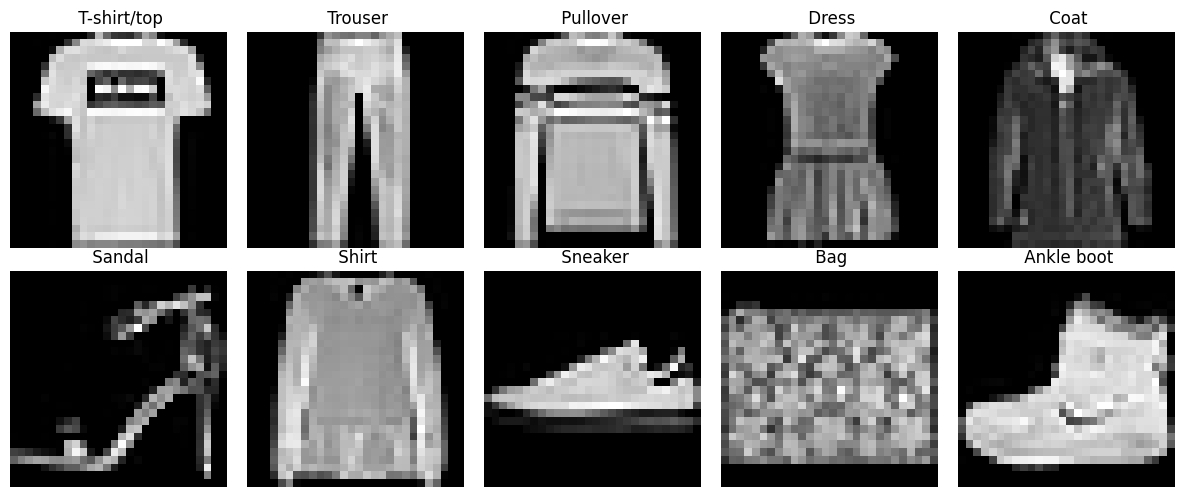

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

for i in range(10):

    for j in range(len(train_labels_all)):

        if train_labels_all[j] == i:

            axes[i].imshow(train_images_all[j], cmap='gray')
            axes[i].set_title(f' {class_names[i]}')
            axes[i].axis('off')



            break

plt.tight_layout()
plt.show()

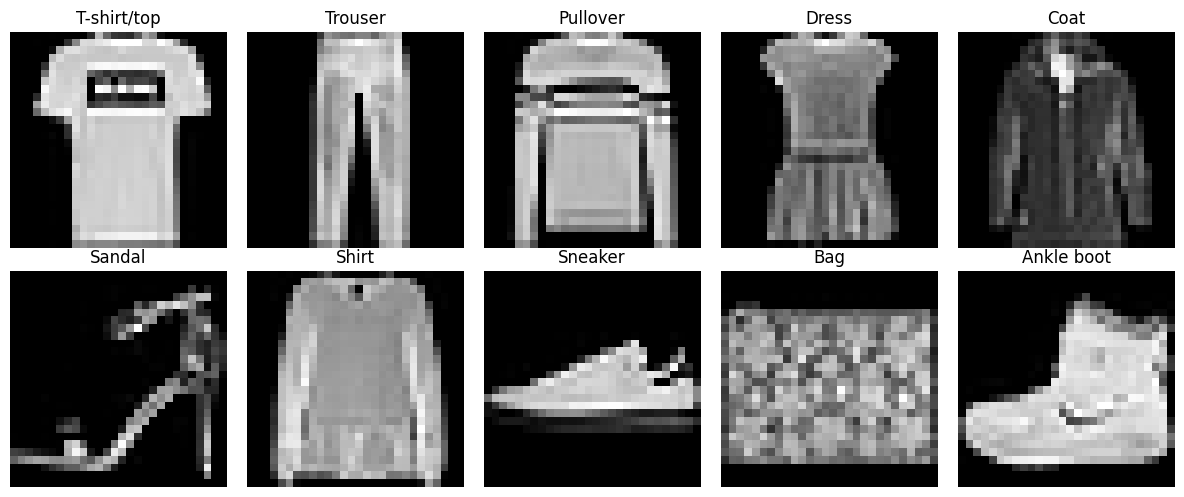

### 2.3 Class Distribution (5 Marks)

Plot a **bar chart** showing how many samples belong to each class in the training set.
- X-axis: class names
- Y-axis: count
- Title: "Training Set Class Distribution"
- Add the count number on top of each bar

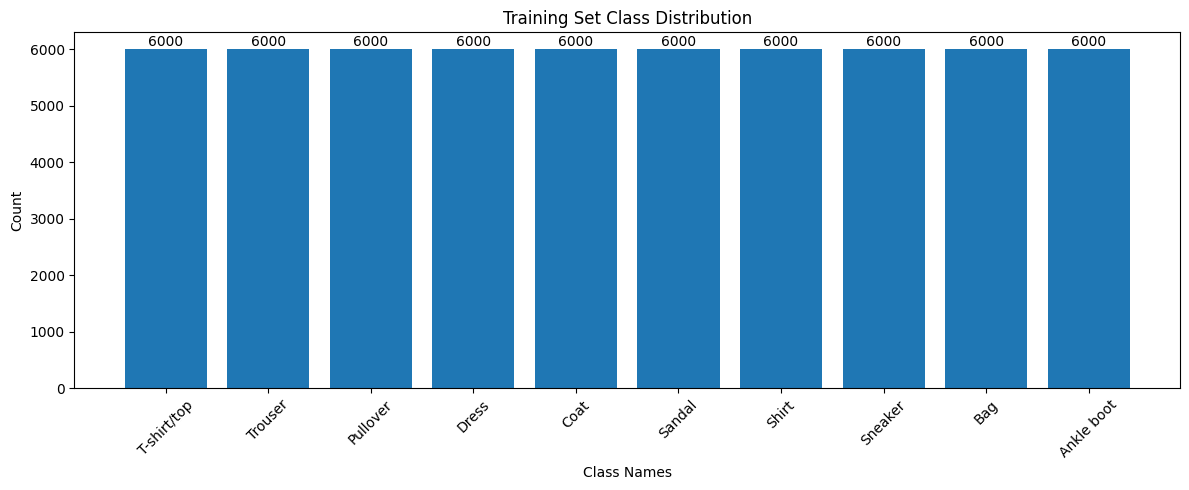

In [8]:
# YOUR CODE HERE
import matplotlib.pyplot as plt


class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
class_counts = []
for i in range(10):
    count = (train_labels_all == i).sum()
    class_counts.append(count)


plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, class_counts)
plt.xlabel('Class Names')
plt.ylabel('Count')
plt.title('Training Set Class Distribution')
for bar, count in zip(bars, class_counts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(count),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.4 Prepare Tensors and Split (4 Marks)

Now we need to extract the data as NumPy arrays, normalize it, split it, and convert to PyTorch tensors.



**Your tasks:**
1. Normalize pixel values to **[0, 1]** by dividing by 255.0.
2. Split training data into **train (50,000)** and **validation (10,000)** using `train_test_split` with `random_state=42`.
3. Convert all sets to PyTorch tensors — images as `float32`, labels as `long`.

**Required variables:** `X_train, X_val, X_test` (tensors), `y_train, y_val, y_test` (tensors)

In [9]:
from sklearn.model_selection import train_test_split

# YOUR CODE HERE
X_train, X_val, y_train, y_val = train_test_split(
    train_images_all, train_labels_all, train_size = 50000,
    test_size = 10000,
    random_state = 42

)

X_train = torch.tensor(X_train, dtype = torch.float32) / 255.0
y_train = torch.tensor(y_train, dtype = torch.long)
X_val = torch.tensor(X_val, dtype = torch.float32) / 255.0
y_val = torch.tensor(y_val, dtype = torch.long)

X_test = torch.tensor(test_images_all, dtype = torch.float32) / 255.0
y_test = torch.tensor(test_labels_all, dtype = torch.long)


In [10]:
# --- TEST CELL (DO NOT MODIFY) ---
assert X_train.shape == (50000, 28, 28), f"Expected X_train shape (50000, 28, 28), got {X_train.shape}"
assert X_val.shape == (10000, 28, 28), f"Expected X_val shape (10000, 28, 28), got {X_val.shape}"
assert X_train.dtype == torch.float32, "X_train should be float32"
assert y_train.dtype == torch.long, "y_train should be long"
assert X_train.max() <= 1.0 and X_train.min() >= 0.0, "Pixel values should be in [0, 1]"
print("✅ Q2.4 Passed!")
print(f"   Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

✅ Q2.4 Passed!
   Train: torch.Size([50000, 28, 28]), Val: torch.Size([10000, 28, 28]), Test: torch.Size([10000, 28, 28])


---

## Question 3: Build DataLoaders (10 Marks)

Create `TensorDataset` and `DataLoader` objects for the train, validation, and test sets.

- **batch_size = 64**
- **shuffle = True** for training, **False** for validation and test

**Required variables:** `train_loader`, `val_loader`, `test_loader`

In [11]:
# YOUR CODE HERE
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = True)

In [12]:
# --- TEST CELL (DO NOT MODIFY) ---
batch_X, batch_y = next(iter(train_loader))
assert batch_X.shape == (64, 28, 28), f"Batch shape should be (64, 28, 28), got {batch_X.shape}"
assert batch_y.dtype == torch.long, "Labels should be torch.long"
assert batch_X.max() <= 1.0, "Images should be normalized"
print("✅ Q3 Passed!")
print(f"   Batch images shape: {batch_X.shape}")
print(f"   Batch labels shape: {batch_y.shape}")

✅ Q3 Passed!
   Batch images shape: torch.Size([64, 28, 28])
   Batch labels shape: torch.Size([64])


---

## Question 4: Define the Model (15 Marks)

Create a class `FashionClassifier` inheriting from `nn.Module`.

Use `nn.Sequential` with this architecture:

| Layer | Description |
|-------|-------------|
| Flatten | Convert 28×28 → 784 |
| Linear | 784 → 256 |
| ReLU | Activation |
| Linear | 256 → 128 |
| ReLU | Activation |
| Linear | 128 → 64 |
| ReLU | Activation |
| Linear | 64 → 10 |

> **Note**: Do NOT apply Softmax at the output layer.

After defining the class:
1. Create an instance of `FashionClassifier`.
2. Print the model architecture.

In [13]:
# YOUR CODE HERE
class FashionClassifier(nn.Module):
  def __init__(self, input_size, num_classes):
    super().__init__()

    self.network = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size,256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Linear(64, num_classes)

    )
  def forward(self,features):
    output = self.network(features)
    return output

In [14]:
model = FashionClassifier(input_size = 28*28, num_classes = 10)
print(model)

FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [15]:
# --- TEST CELL (DO NOT MODIFY) ---
test_input = torch.randn(5, 28, 28)
test_output = model(test_input)
assert test_output.shape == (5, 10), f"Output shape should be (5, 10), got {test_output.shape}"
total_params = sum(p.numel() for p in model.parameters())
assert total_params > 0, "Model should have trainable parameters"
print("✅ Q4 Passed!")
print(f"   Total parameters: {total_params}")
print(model)

✅ Q4 Passed!
   Total parameters: 242762
FashionClassifier(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)


---

## Question 5: Train the Model (25 Marks)

### 5.1 Set Up Training (5 Marks)
- Loss function: `nn.CrossEntropyLoss`
- Optimizer: `optim.SGD` with `lr=0.01`
- Number of epochs: **15**

In [16]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr = 0.1)

### 5.2 Training Loop (15 Marks)

Write a complete training loop for **15 epochs**.

For each epoch:
- Train on `train_loader` and compute training loss
- Evaluate on `val_loader` (with `torch.no_grad()`) and compute validation loss
- Print: `Epoch {epoch+1}/{epochs} | Train Loss: {:.4f} | Val Loss: {:.4f} `

Store: `train_losses`, `val_losses`, (lists, one value per epoch).

In [21]:
epochs = 15

train_losses = []
val_losses = []

for epoch in range(epochs):

    
    train_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    
    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)


    
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)


    
    print(
        f'Epoch {epoch+1}/{epochs} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f}'
    )

Epoch 1/15 | Train Loss: 0.2296 | Val Loss: 0.3721
Epoch 2/15 | Train Loss: 0.2251 | Val Loss: 0.3620
Epoch 3/15 | Train Loss: 0.2216 | Val Loss: 0.3595
Epoch 4/15 | Train Loss: 0.2119 | Val Loss: 0.4351
Epoch 5/15 | Train Loss: 0.2098 | Val Loss: 0.3664
Epoch 6/15 | Train Loss: 0.2021 | Val Loss: 0.3530
Epoch 7/15 | Train Loss: 0.1943 | Val Loss: 0.3349
Epoch 8/15 | Train Loss: 0.1912 | Val Loss: 0.4660
Epoch 9/15 | Train Loss: 0.1862 | Val Loss: 0.5892
Epoch 10/15 | Train Loss: 0.1858 | Val Loss: 0.3984
Epoch 11/15 | Train Loss: 0.1807 | Val Loss: 0.4645
Epoch 12/15 | Train Loss: 0.1756 | Val Loss: 0.3485
Epoch 13/15 | Train Loss: 0.1712 | Val Loss: 0.3386
Epoch 14/15 | Train Loss: 0.1675 | Val Loss: 0.3923
Epoch 15/15 | Train Loss: 0.1619 | Val Loss: 0.4148


In [31]:
val_accuracies = []
train_accuracies = []

In [32]:
with torch.no_grad():
    y_pred_prob = model(X_val)
    y_pred = torch.argmax(y_pred_prob, dim=1)

    val_accuracy = (y_pred == y_val).float().mean() * 100
    val_accuracies.append(val_accuracy.item())

print(f"Accuracy: {val_accuracy:.2f}%")

Accuracy: 87.31%


In [33]:
with torch.no_grad():
    y_pred_prob = model(X_train)
    y_pred = torch.argmax(y_pred_prob, dim=1)

    train_accuracy = (y_pred == y_train).float().mean() * 100
    train_accuracies.append(train_accuracy.item())

print(f"Accuracy: {train_accuracy:.2f}%")

Accuracy: 91.77%


In [34]:
# --- TEST CELL (DO NOT MODIFY) ---
assert len(train_losses) == 15, f"Expected 15 epochs, got {len(train_losses)}"
assert len(val_losses) == 15
assert train_losses[-1] < train_losses[0], "Training loss should decrease"
print("✅ Q5.2 Passed!")
print(f"   Final Train Acc: {train_accuracies[-1]:.2f}%, Final Val Acc: {val_accuracies[-1]:.2f}%")

✅ Q5.2 Passed!
   Final Train Acc: 91.77%, Final Val Acc: 87.31%


### 5.3 Test Evaluation (5 Marks)

Evaluate the model on the **test set**. Print the test_accuracy (required_variable)

Also, collect all test predictions and true labels into lists called `all_preds` and `all_labels` (we'll use them for analysis later).

Print: `Test Accuracy: {:.2f}%`

In [39]:
# YOUR CODE HERE
with torch.no_grad():
    y_pred_prob = model(X_test)
    all_preds = torch.argmax(y_pred_prob, dim=1)

    test_accuracy = (all_preds == y_test).float().mean() * 100
    

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 87.01%


In [40]:
# --- TEST CELL (DO NOT MODIFY) ---
assert test_accuracy > 40.0, f"Test accuracy should be > 40%, got {test_accuracy:.2f}%"
assert len(all_preds) == len(X_test), "Predictions should cover all test samples"
print(f"✅ Q5.3 Passed! Test Accuracy: {test_accuracy:.2f}%")

✅ Q5.3 Passed! Test Accuracy: 87.01%


---

## Question 6: Visualize & Analyze Results (25 Marks)

### 6.1 Plot Training Loss vs Validation Loss (5 Marks)

Plot **Training Loss** and **Validation Loss** on the same figure across epochs.
- Include a legend, title ("Loss Curve"), and axis labels.

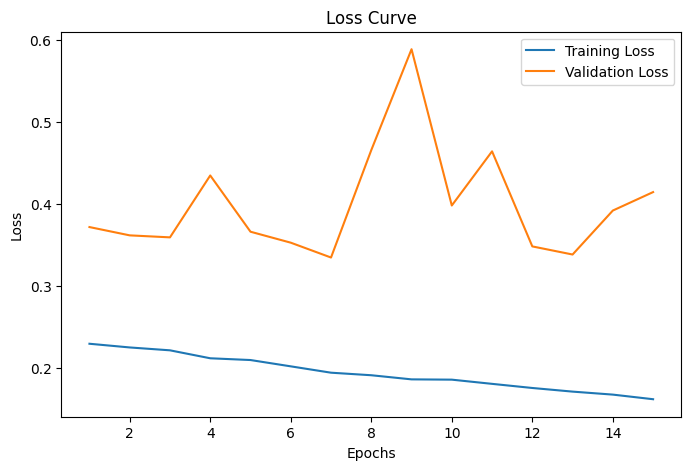

In [41]:
# YOUR CODE HERE
import matplotlib.pyplot as plt
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 6.2 Plot Training Accuracy vs Validation Accuracy (5 Marks)

Plot **Training Accuracy** and **Validation Accuracy** on the same figure across epochs.
- Include a legend, title ("Accuracy Curve"), and axis labels.

In [54]:
epochs = 15

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    train_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss = train_loss / len(train_loader)
    train_losses.append(train_loss)


    

    with torch.no_grad():
        y_pred_prob = model(X_train)
        y_pred = torch.argmax(y_pred_prob, dim=1)

        train_accuracy = (y_pred == y_train).float().mean() * 100
        train_accuracies.append(train_accuracy.item())


    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)


    

    with torch.no_grad():
        y_pred_prob = model(X_val)
        y_pred = torch.argmax(y_pred_prob, dim=1)

        val_accuracy = (y_pred == y_val).float().mean() * 100
        val_accuracies.append(val_accuracy.item())


    print(
        f'Epoch {epoch+1}/{epochs} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Validation Loss: {val_loss:.4f}'
    )

Epoch 1/15 | Train Loss: 0.1599 | Validation Loss: 0.3669
Epoch 2/15 | Train Loss: 0.1544 | Validation Loss: 0.4898
Epoch 3/15 | Train Loss: 0.1507 | Validation Loss: 0.4080
Epoch 4/15 | Train Loss: 0.1483 | Validation Loss: 0.4021
Epoch 5/15 | Train Loss: 0.1440 | Validation Loss: 0.4398
Epoch 6/15 | Train Loss: 0.1422 | Validation Loss: 0.3668
Epoch 7/15 | Train Loss: 0.1371 | Validation Loss: 0.4070
Epoch 8/15 | Train Loss: 0.1318 | Validation Loss: 0.4173
Epoch 9/15 | Train Loss: 0.1315 | Validation Loss: 0.4774
Epoch 10/15 | Train Loss: 0.1249 | Validation Loss: 0.4046
Epoch 11/15 | Train Loss: 0.1237 | Validation Loss: 0.3619
Epoch 12/15 | Train Loss: 0.1212 | Validation Loss: 0.4025
Epoch 13/15 | Train Loss: 0.1216 | Validation Loss: 0.4482
Epoch 14/15 | Train Loss: 0.1206 | Validation Loss: 0.4293
Epoch 15/15 | Train Loss: 0.1174 | Validation Loss: 0.4449


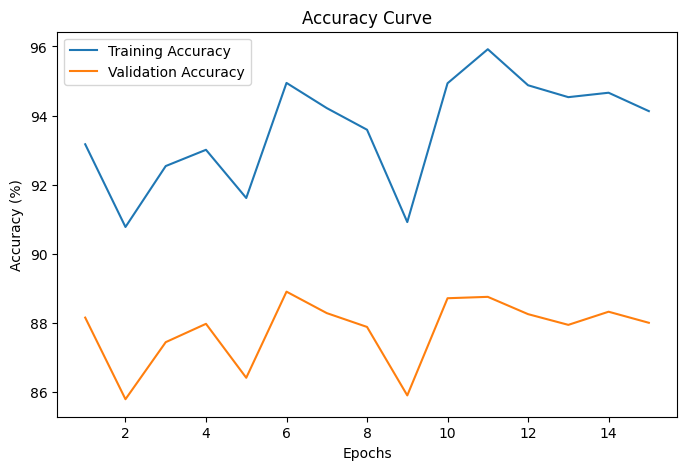

In [55]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_accuracies, label="Training Accuracy")
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")

plt.legend()
plt.show()

### 6.3 Confusion Matrix (5 Marks)

Using `sklearn.metrics`:
1. Compute the confusion matrix on test predictions.
2. Display it as a heatmap using `ConfusionMatrixDisplay` with `class_names` as labels.
3. Title: "StyleAI Fashion Classifier — Test Confusion Matrix"

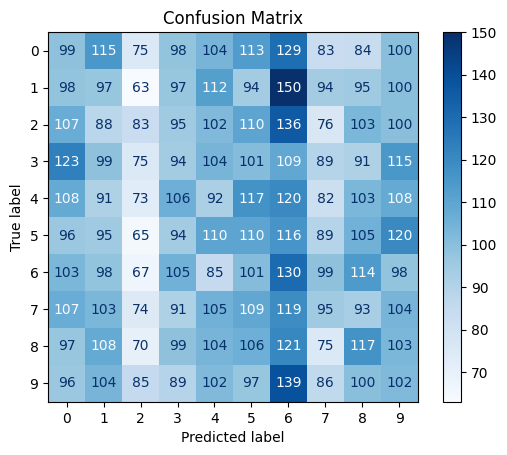

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_test = y_test.cpu().numpy()
y_pred= y_pred.cpu().numpy()
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10)) 
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
     

### 6.4 Classification Report (5 Marks)

Print the `classification_report` from sklearn using `target_names=class_names`.

In [57]:
from sklearn.metrics import classification_report

# YOUR CODE HERE
from sklearn.metrics import classification_report

with torch.no_grad():
    y_pred_prob = model(X_val)
    y_pred = torch.argmax(y_pred_prob, dim=1)

print(classification_report(
    y_val.cpu(),
    y_pred.cpu(),
    target_names=class_names
))

              precision    recall  f1-score   support

 T-shirt/top       0.83      0.86      0.84      1009
     Trouser       0.98      0.98      0.98      1002
    Pullover       0.90      0.66      0.76       997
       Dress       0.91      0.88      0.90      1008
        Coat       0.80      0.81      0.81       997
      Sandal       0.94      0.98      0.96      1015
       Shirt       0.65      0.81      0.72      1016
     Sneaker       0.97      0.89      0.93       947
         Bag       0.96      0.96      0.96      1001
  Ankle boot       0.92      0.96      0.94      1008

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



### 6.5 Written Analysis (5 Marks)

In the markdown cell below, answer:
1. Which two classes are **most often confused** with each other? Look at the confusion matrix and explain **why** (think about visual similarity).
2. Is the model **overfitting or underfitting**? How can you tell from the learning curves?

*Double-click here to write your analysis*

**Your Analysis:**
1. From Confusion matrix and visually looking at the image data, 1 and 6 are most confused. Trouser and shirts edges are quite similar, trouseer has two legs going down
on the other hand, in terms of shirt also, there are two hand going downwards.

2. The model is overfitting. The model is giving good accuracy doing training phase but in terms of validation, it fails to produce this kinda acuracy. 
